# GrC full manual-morphology debug

Debug notebook for the full granule-cell comparison. Both NEURON and BrainCell use ASC soma/dend sections plus manually reconstructed hilock, AIS, ascending axon, and the two PF chains from the source script. Synapses remain excluded. The default full-channel clamp is small for numerical stability; raise `amp_nA` manually when testing stronger stimulation.

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "True")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import brainunit as u
from neuron import h

def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.neuron_compare.cell.grc_ma2020.debug.grc_full_parameters import (
    GrCFullConfig,
    GrCFullToggles,
    full_toggle_names,
    load_grc20_full_params,
)
from examples.neuron_compare.cell.grc_ma2020.debug.grc_full_neuron_debug import GrCFull as NeuronGrCFull
from examples.neuron_compare.cell.grc_ma2020.debug.grc_full_braincell_debug import GrCFull as BrainCellGrCFull

import braincell
from braincell import mech
from braincell.filter import at
import brainstate
import jax
import jax.numpy as jnp
brainstate.environ.set(precision=64)
print("braincell import:", braincell.__file__)
print(
    "precision:",
    {
        "jax_enable_x64": bool(jax.config.read("jax_enable_x64")),
        "jnp_default_dtype": str(jnp.asarray([1.0]).dtype),
        "brainstate_dftype": str(brainstate.environ.dftype()),
    },
)

--No graphics will be displayed.


braincell import: /home/swl/braincell-ion_dyn/braincell/__init__.py
precision: {'jax_enable_x64': True, 'jnp_default_dtype': 'float64', 'brainstate_dftype': "<class 'numpy.float64'>"}


In [2]:
params = load_grc20_full_params()

# Presets: "all", "leak_only", "sodium_axon", "calcium_only", "cdp_calcium", "manual".
# Use "manual" when you want direct control of every channel/ion below.
toggle_mode = "manual"

# Passive current.
leak = True

# Sodium channels on manual axon/PF regions.
nav = True
nafhhf = True

# Potassium channels.
kv3p4 = True
kv4p3 = True
kir2p3 = True
kv1p1 = True
kv1p5 = True
kv2p2 = True
km = True

# Calcium channels.
cahva = True

# Calcium-activated potassium channels.
kca1p1 = True

# Calcium ion/pool. When False, calcium-dependent/channel tests use CalciumFixed if needed.
cdp = True

manual_toggles = {
    "leak": leak,
    "nav": nav,
    "nafhhf": nafhhf,
    "kv3p4": kv3p4,
    "kv4p3": kv4p3,
    "kir2p3": kir2p3,
    "cahva": cahva,
    "kv1p1": kv1p1,
    "kv1p5": kv1p5,
    "kv2p2": kv2p2,
    "kca1p1": kca1p1,
    "km": km,
    "cdp": cdp,
}

def make_toggles(mode="all", **overrides):
    names = full_toggle_names()
    if mode == "all":
        values = {name: True for name in names}
    elif mode == "leak_only":
        values = {name: False for name in names}
        values["leak"] = True
    elif mode == "sodium_axon":
        values = {name: False for name in names}
        values.update({"leak": True, "nav": True, "nafhhf": True})
    elif mode == "calcium_only":
        values = {name: False for name in names}
        values.update({"leak": True, "cahva": True})
    elif mode == "cdp_calcium":
        values = {name: False for name in names}
        values.update({"leak": True, "cahva": True, "cdp": True})
    elif mode == "manual":
        values = {name: bool(manual_toggles.get(name, False)) for name in names}
    else:
        raise ValueError(f"Unknown toggle_mode {mode!r}.")
    values.update({key: bool(value) for key, value in overrides.items()})
    return GrCFullToggles(**values)

# Example override: make_toggles("all", kv2p2=False, cdp=False)
toggles = make_toggles(toggle_mode)
config = GrCFullConfig(toggles=toggles, temperature_celsius=25.0, v_init_mV=-65.0)

dt_ms = 0.1
duration_ms = 30.0
delay_ms = 5.0
stim_dur_ms = 50.0
amp_nA = 0.02

asc_only = False
manual_pf = True

display(pd.DataFrame(
    [
        {"group": "passive", "name": "leak", "enabled": toggles.leak},
        {"group": "sodium", "name": "nav", "enabled": toggles.nav},
        {"group": "sodium", "name": "nafhhf", "enabled": toggles.nafhhf},
        {"group": "potassium", "name": "kv3p4", "enabled": toggles.kv3p4},
        {"group": "potassium", "name": "kv4p3", "enabled": toggles.kv4p3},
        {"group": "potassium", "name": "kir2p3", "enabled": toggles.kir2p3},
        {"group": "potassium", "name": "kv1p1", "enabled": toggles.kv1p1},
        {"group": "potassium", "name": "kv1p5", "enabled": toggles.kv1p5},
        {"group": "potassium", "name": "kv2p2", "enabled": toggles.kv2p2},
        {"group": "potassium", "name": "km", "enabled": toggles.km},
        {"group": "calcium_channel", "name": "cahva", "enabled": toggles.cahva},
        {"group": "kca", "name": "kca1p1", "enabled": toggles.kca1p1},
        {"group": "ion", "name": "cdp", "enabled": toggles.cdp},
    ]
))

print(f"toggle_mode={toggle_mode}, asc_only={asc_only}, manual_pf={manual_pf}")
print(f"dt={dt_ms} ms, duration={duration_ms} ms, clamp={amp_nA} nA")

,group,name,enabled
0,passive,leak,True
1,sodium,nav,True
2,sodium,nafhhf,True
3,potassium,kv3p4,True
4,potassium,kv4p3,True
5,potassium,kir2p3,True
6,potassium,kv1p1,True
7,potassium,kv1p5,True
8,potassium,kv2p2,True
9,potassium,km,True


toggle_mode=manual, asc_only=False, manual_pf=True
dt=0.1 ms, duration=30.0 ms, clamp=0.02 nA


In [3]:
neuron_cell = NeuronGrCFull(params=params, config=config).build()
braincell_cell = BrainCellGrCFull(params=params, config=config).build()

pd.DataFrame([neuron_cell.summary(), braincell_cell.summary()])[[
    "backend", "asc_only", "manual_pf", "branch_counts", "region_counts", "compartment_counts"
]]


103 lines read


/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 3 zero-length segment(s) from coincident consecutive points at index pair(s) [1, 3, 5]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(


,backend,asc_only,manual_pf,branch_counts,region_counts,compartment_counts
0,neuron,False,True,"{'n_soma': 1, 'n_dend': 4, 'n_axon': 290, 'n_t...","{'aa': 4, 'ais': 1, 'dend': 4, 'hilock': 1, 'p...",{'n_total_nseg': 295}
1,braincell,False,True,"{'n_soma': 1, 'n_dend': 4, 'n_axon': 290, 'n_t...","{'aa': 4, 'ais': 1, 'dend': 4, 'hilock': 1, 'p...",{'n_total_cv': 295}


In [4]:
neuron_cell.branch_table()

,branch_index,branch_name,branch_type,source_region,source_local_index,diam_um,diam_arc_mean_um,cm_uF_cm2,nseg,has_cahva,...,has_km,has_kv1p1,has_kv1p5,has_kv2p2,has_kv3p4,has_kv4p3,has_leak,has_nafhhf,has_nav,enabled_mechanisms
0,0,soma[0],soma,soma,0,4.565836,4.565836,2.0,1,True,...,False,True,True,True,True,True,True,False,False,"[cahva, cdp, kir2p3, kv1p1, kv1p5, kv2p2, kv3p..."
1,1,dend[0],dendrite,dend,0,0.750000,0.750000,2.5,1,True,...,False,True,False,False,False,False,True,False,False,"[cahva, cdp, kca1p1, kv1p1, leak]"
2,2,dend[1],dendrite,dend,1,0.750000,0.750000,2.5,1,True,...,False,True,False,False,False,False,True,False,False,"[cahva, cdp, kca1p1, kv1p1, leak]"
3,3,dend[2],dendrite,dend,2,0.750000,0.750000,2.5,1,True,...,False,True,False,False,False,False,True,False,False,"[cahva, cdp, kca1p1, kv1p1, leak]"
4,4,dend[3],dendrite,dend,3,0.750000,0.750000,2.5,1,True,...,False,True,False,False,False,False,True,False,False,"[cahva, cdp, kca1p1, kv1p1, leak]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,290,pf2_137,axon,pf,137,0.150000,0.150000,1.0,1,True,...,False,False,False,False,True,False,True,False,True,"[cahva, cdp, kv3p4, leak, nav]"
291,291,pf2_138,axon,pf,138,0.150000,0.150000,1.0,1,True,...,False,False,False,False,True,False,True,False,True,"[cahva, cdp, kv3p4, leak, nav]"
292,292,pf2_139,axon,pf,139,0.150000,0.150000,1.0,1,True,...,False,False,False,False,True,False,True,False,True,"[cahva, cdp, kv3p4, leak, nav]"
293,293,pf2_140,axon,pf,140,0.150000,0.150000,1.0,1,True,...,False,False,False,False,True,False,True,False,True,"[cahva, cdp, kv3p4, leak, nav]"


In [5]:
braincell_cell.branch_table()

,branch_index,branch_name,branch_type,source_region,source_local_index,diam_arc_mean_um,cm_uF_cm2,n_cv,has_cahva,has_cdp,...,has_km,has_kv1p1,has_kv1p5,has_kv2p2,has_kv3p4,has_kv4p3,has_leak,has_nafhhf,has_nav,enabled_mechanisms
0,0,soma,soma,soma,0,4.565836,2.0,1,True,True,...,False,True,True,True,True,True,True,False,False,"[cahva, cdp, kir2p3, kv1p1, kv1p5, kv2p2, kv3p..."
1,1,dendrite_0,dendrite,dend,0,0.750000,2.5,1,True,True,...,False,True,False,False,False,False,True,False,False,"[cahva, cdp, kca1p1, kv1p1, leak]"
2,2,dendrite_1,dendrite,dend,1,0.750000,2.5,1,True,True,...,False,True,False,False,False,False,True,False,False,"[cahva, cdp, kca1p1, kv1p1, leak]"
3,3,dendrite_2,dendrite,dend,2,0.750000,2.5,1,True,True,...,False,True,False,False,False,False,True,False,False,"[cahva, cdp, kca1p1, kv1p1, leak]"
4,4,dendrite_3,dendrite,dend,3,0.750000,2.5,1,True,True,...,False,True,False,False,False,False,True,False,False,"[cahva, cdp, kca1p1, kv1p1, leak]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,290,pf2_137,axon,pf,137,0.150000,1.0,1,True,True,...,False,False,False,False,True,False,True,False,True,"[cahva, cdp, kv3p4, leak, nav]"
291,291,pf2_138,axon,pf,138,0.150000,1.0,1,True,True,...,False,False,False,False,True,False,True,False,True,"[cahva, cdp, kv3p4, leak, nav]"
292,292,pf2_139,axon,pf,139,0.150000,1.0,1,True,True,...,False,False,False,False,True,False,True,False,True,"[cahva, cdp, kv3p4, leak, nav]"
293,293,pf2_140,axon,pf,140,0.150000,1.0,1,True,True,...,False,False,False,False,True,False,True,False,True,"[cahva, cdp, kv3p4, leak, nav]"


In [6]:
DT_MS = dt_ms
DURATION_MS = duration_ms
DELAY_MS = delay_ms
STIM_DUR_MS = stim_dur_ms
AMP_NA = amp_nA

nrn_probes = neuron_cell.attach_voltage_probes(all_compartments=True, soma=True)
bc_probes = braincell_cell.attach_voltage_probes(all_compartments=True, soma=True)

stim = h.IClamp(neuron_cell.root_soma(0.5))
stim.delay = DELAY_MS
stim.dur = STIM_DUR_MS
stim.amp = AMP_NA
stim_i = h.Vector().record(stim._ref_i)
h.cvode_active(0)
h.dt = DT_MS
h.steps_per_ms = 1.0 / h.dt
h.celsius = config.temperature_celsius
h.tstop = DURATION_MS
h.v_init = config.v_init_mV
t_neuron = h.Vector().record(h._ref_t)
h.finitialize(h.v_init)
h.run()

braincell_cell.cell.place(
    at("soma", 0.5),
    mech.CurrentClamp(delay=DELAY_MS * u.ms, durations=STIM_DUR_MS * u.ms, amplitudes=AMP_NA * u.nA),
)
braincell_cell.cell.init_state()

def _ion_summary(cell, name):
    try:
        ion = cell.get_ion(name)
    except (KeyError, RuntimeError) as exc:
        return {"ion": name, "class": "not painted", "note": str(exc)}
    units = {"E": u.mV, "Ci": u.mM, "Co": u.mM}
    row = {"ion": name, "class": type(ion).__name__}
    for field, unit in units.items():
        if hasattr(ion, field):
            values = np.asarray(getattr(ion, field).to_decimal(unit), dtype=float).reshape(-1)
            row[f"{field}_unique"] = np.unique(np.round(values, 12)).tolist()
    return row

display(pd.DataFrame([
    _ion_summary(braincell_cell.cell, name)
    for name in ("k", "na", "no")
    if name in ("k", "na") or toggles.kv1p5
]))
print(
    "BrainCell K/Na ions use Nernst-initialized reversal potentials from their Ci/Co values and config temperature; "
    "Kv1p5 BrainCell binding uses Kv1p5_MA2020_GrC with ion_names={'k': 'k', 'na': 'na', 'no': 'no'}."
)
braincell_cell.cell.reset_state()
bc_run = braincell_cell.cell.run(dt=DT_MS * u.ms, duration=DURATION_MS * u.ms)

nrn_v = neuron_cell.collect_voltage_results(nrn_probes)
bc_v = braincell_cell.collect_voltage_results(bc_probes, bc_run)
t_neuron = np.asarray(t_neuron, dtype=float)
stim_i = np.asarray(stim_i, dtype=float)
t_bc = np.arange(1, len(bc_v["soma_voltage_mV"]) + 1, dtype=float) * DT_MS
nrn_soma_for_bc = np.interp(t_bc, t_neuron, nrn_v["soma_voltage_mV"])
delta = bc_v["soma_voltage_mV"] - nrn_soma_for_bc
{
    "applied_amp_nA": float(AMP_NA),
    "neuron_stim_i_max_nA": float(np.max(stim_i)) if len(stim_i) else None,
    "neuron_stim_i_min_nA": float(np.min(stim_i)) if len(stim_i) else None,
    "n_neuron_samples": int(len(t_neuron)),
    "n_braincell_samples": int(len(t_bc)),
    "soma_max_abs_mV": float(np.max(np.abs(delta))),
    "soma_mean_abs_mV": float(np.mean(np.abs(delta))),
}

,ion,class,E_unique,Ci_unique,Co_unique
0,k,PotassiumInitNernst,"[-82.05465219958, -79.135030093174]",[54.4],[2.5]
1,na,SodiumInitNernst,"[67.804189246222, 70.305769262014]",[10.0],[140.0]
2,no,NonSpecificFixed,[0.0],[1.0],[1.0]


BrainCell K/Na ions use Nernst-initialized reversal potentials from their Ci/Co values and config temperature; Kv1p5 BrainCell binding uses Kv1p5_MA2020_GrC with ion_names={'k': 'k', 'na': 'na', 'no': 'no'}.


{'applied_amp_nA': 0.02,
 'neuron_stim_i_max_nA': 0.02,
 'neuron_stim_i_min_nA': 0.0,
 'n_neuron_samples': 301,
 'n_braincell_samples': 300,
 'soma_max_abs_mV': 0.26812396494633006,
 'soma_mean_abs_mV': 0.004475459189855636}

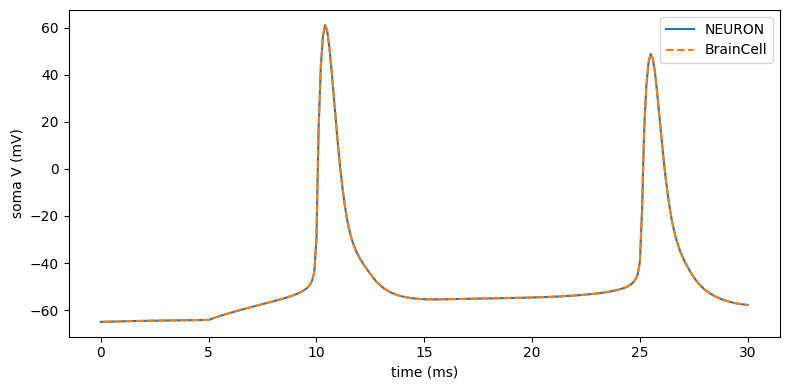

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(t_neuron, nrn_v["soma_voltage_mV"], label="NEURON")
plt.plot(t_bc, bc_v["soma_voltage_mV"], label="BrainCell", linestyle="--")
plt.xlabel("time (ms)")
plt.ylabel("soma V (mV)")
plt.legend()
plt.tight_layout()